In [2]:
%pip install pycocotools

Note: you may need to restart the kernel to use updated packages.


In [5]:
# import os
# import urllib.request
# import zipfile

# os.makedirs('annotations', exist_ok=True)

# # Download COCO annotations
# url = 'http://images.cocodataset.org/annotations/annotations_trainval2017.zip'
# zip_path = 'annotations_trainval2017.zip'

# print("Downloading COCO annotations (this may take a few minutes)...")
# urllib.request.urlretrieve(url, zip_path)

# print("Extracting...")
# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall('.')

# # Move the annotations to the right place
# import shutil
# if os.path.exists('annotations/instances_val2017.json'):
#     print("✓ Successfully downloaded and extracted!")
# else:
#     print("Files extracted to:", os.listdir('annotations'))

In [ ]:
import concurrent.futures
import os
from pycocotools.coco import COCO
import urllib.request
from collections import defaultdict

coco = COCO('annotations/instances_val2017.json')
img_ids = coco.getImgIds()
output_dir = "val2017"
os.makedirs(output_dir, exist_ok=True)


loading annotations into memory...
Done (t=0.38s)
creating index...
index created!


5000

In [4]:
print(f"Total images: {len(img_ids)}")

Total images: 5000


In [6]:
print("Total Classes:", len(coco.getCatIds()))

Total Classes: 80


In [7]:
print(coco.loadImgs(img_ids[0:2]))

[{'license': 4, 'file_name': '000000397133.jpg', 'coco_url': 'http://images.cocodataset.org/val2017/000000397133.jpg', 'height': 427, 'width': 640, 'date_captured': '2013-11-14 17:02:52', 'flickr_url': 'http://farm7.staticflickr.com/6116/6255196340_da26cf2c9e_z.jpg', 'id': 397133}, {'license': 1, 'file_name': '000000037777.jpg', 'coco_url': 'http://images.cocodataset.org/val2017/000000037777.jpg', 'height': 230, 'width': 352, 'date_captured': '2013-11-14 20:55:31', 'flickr_url': 'http://farm9.staticflickr.com/8429/7839199426_f6d48aa585_z.jpg', 'id': 37777}]


In [9]:
ann_ids = coco.getAnnIds(imgIds=img_ids)
annotations = coco.loadAnns(ann_ids)

In [13]:
ground_truth_objects = set()
imgs_for_each_cat = defaultdict(list)
count_for_each_cats = defaultdict(int)
for ann in annotations:
    category_id = ann['category_id']
    cat_info = coco.loadCats(category_id)[0]
    class_name = cat_info['name']
    ground_truth_objects.add((category_id, class_name))
    count_for_each_cats[class_name] += 1
    imgs_for_each_cat[category_id].append(ann['image_id'])


# print(len(imgs_for_each_cat[18]))  # Number of images containing 'person'
for id, name in ground_truth_objects:
    print(f"Category ID: {id}, Class Name: {name}")

Category ID: 67, Class Name: dining table
Category ID: 38, Class Name: kite
Category ID: 33, Class Name: suitcase
Category ID: 2, Class Name: bicycle
Category ID: 70, Class Name: toilet
Category ID: 63, Class Name: couch
Category ID: 74, Class Name: mouse
Category ID: 24, Class Name: zebra
Category ID: 75, Class Name: remote
Category ID: 73, Class Name: laptop
Category ID: 28, Class Name: umbrella
Category ID: 14, Class Name: parking meter
Category ID: 85, Class Name: clock
Category ID: 90, Class Name: toothbrush
Category ID: 21, Class Name: cow
Category ID: 15, Class Name: bench
Category ID: 89, Class Name: hair drier
Category ID: 87, Class Name: scissors
Category ID: 1, Class Name: person
Category ID: 53, Class Name: apple
Category ID: 81, Class Name: sink
Category ID: 18, Class Name: dog
Category ID: 57, Class Name: carrot
Category ID: 86, Class Name: vase
Category ID: 5, Class Name: airplane
Category ID: 62, Class Name: chair
Category ID: 42, Class Name: surfboard
Category ID: 82, 

In [16]:
print(len(count_for_each_cats))
count_for_each_cats = dict(sorted(count_for_each_cats.items(), key=lambda item: item[1], reverse=True))

80


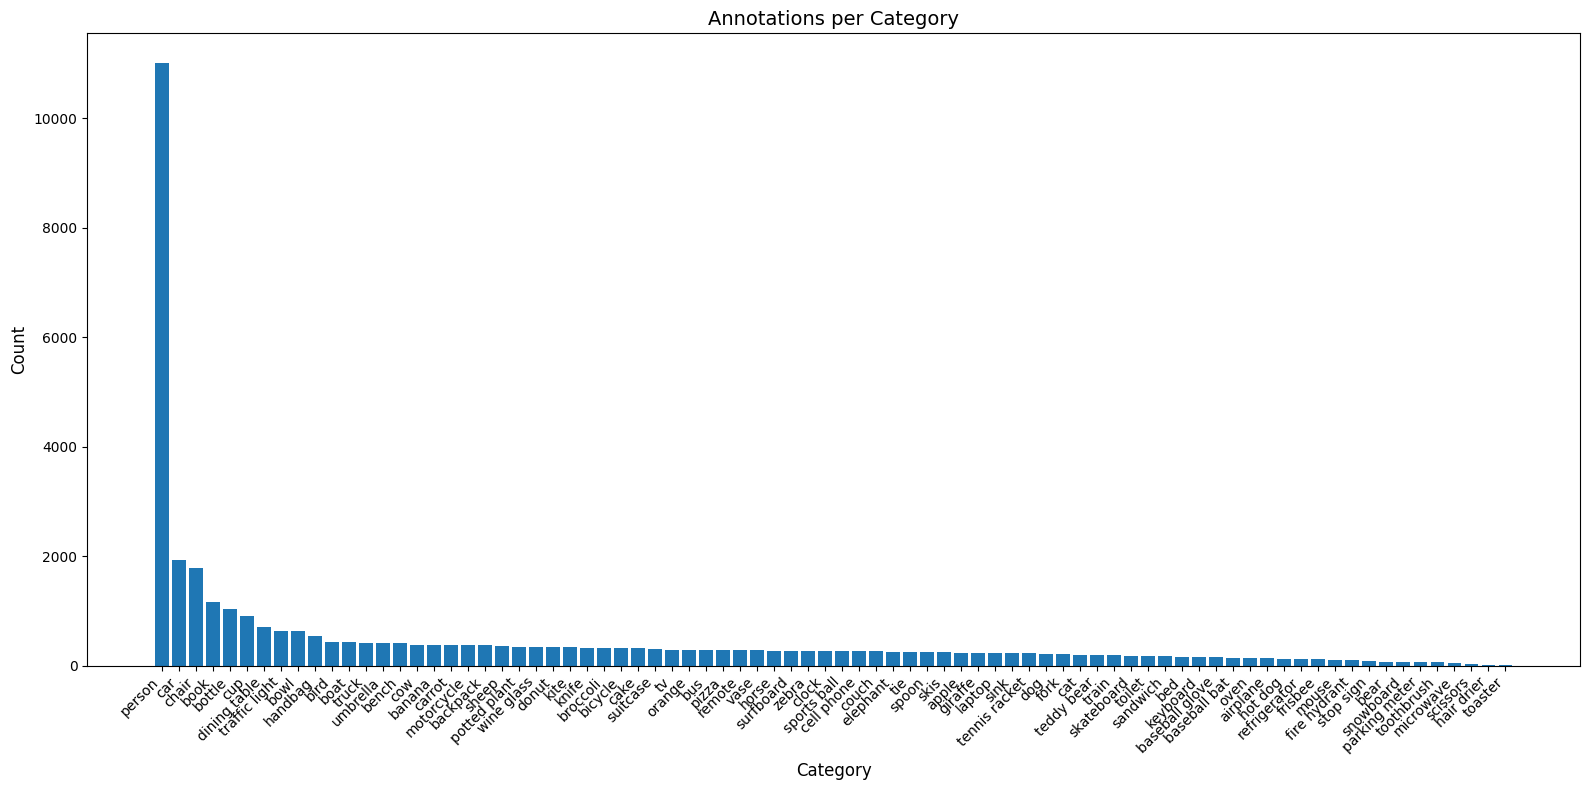

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(16, 8))
plt.bar(count_for_each_cats.keys(), count_for_each_cats.values())
plt.xlabel('Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Annotations per Category', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()